In [16]:
# Import required libraries for data handling, visualization, and ML
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
#scikit library
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

In [17]:
# read the NSL-KDD dataset
df=pd.read_csv("kdd.csv")
# Remove unnecessary index column
if 'Unnamed: 0' in df.columns:
    df = df.drop('Unnamed: 0', axis=1)

In [18]:
#display the head i.e the first 5 records
df.head()

,duration,protocol_type,service,flag,src_bytes,dst_bytes,land,wrong_fragment,urgent,hot,...,dst_host_srv_count,dst_host_same_srv_rate,dst_host_diff_srv_rate,dst_host_same_src_port_rate,dst_host_srv_diff_host_rate,dst_host_serror_rate,dst_host_srv_serror_rate,dst_host_rerror_rate,dst_host_srv_rerror_rate,labels
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,25,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal
1,0,udp,other,SF,146,0,0,0,0,0,...,1,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal
2,0,tcp,private,S0,0,0,0,0,0,0,...,26,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune
3,0,tcp,http,SF,232,8153,0,0,0,0,...,255,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal
4,0,tcp,http,SF,199,420,0,0,0,0,...,255,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal


In [19]:
#rows vs columns defining shape of the dataset
df.shape

(148517, 42)

In [20]:
list(df.columns)

['duration',
 'protocol_type',
 'service',
 'flag',
 'src_bytes',
 'dst_bytes',
 'land',
 'wrong_fragment',
 'urgent',
 'hot',
 'num_failed_logins',
 'logged_in',
 'num_compromised',
 'root_shell',
 'su_attempted',
 'num_root',
 'num_file_creations',
 'num_shells',
 'num_access_files',
 'num_outbound_cmds',
 'is_host_login',
 'is_guest_login',
 'count',
 'srv_count',
 'serror_rate',
 'srv_serror_rate',
 'rerror_rate',
 'srv_rerror_rate',
 'same_srv_rate',
 'diff_srv_rate',
 'srv_diff_host_rate',
 'dst_host_count',
 'dst_host_srv_count',
 'dst_host_same_srv_rate',
 'dst_host_diff_srv_rate',
 'dst_host_same_src_port_rate',
 'dst_host_srv_diff_host_rate',
 'dst_host_serror_rate',
 'dst_host_srv_serror_rate',
 'dst_host_rerror_rate',
 'dst_host_srv_rerror_rate',
 'labels']

In [21]:
# If dataset does not contain 'label' column, assign proper column names

if 'labels' not in df.columns:
    df.columns = [
    'duration','protocol_type','service','flag','src_bytes','dst_bytes','land','wrong_fragment',
    'urgent','hot','num_failed_logins','logged_in','num_compromised','root_shell','su_attempted',
    'num_root','num_file_creations','num_shells','num_access_files','num_outbound_cmds',
    'is_host_login','is_guest_login','count','srv_count','serror_rate','srv_serror_rate',
    'rerror_rate','srv_rerror_rate','same_srv_rate','diff_srv_rate','srv_diff_host_rate',
    'dst_host_count','dst_host_srv_count','dst_host_same_srv_rate','dst_host_diff_srv_rate',
    'dst_host_same_src_port_rate','dst_host_srv_diff_host_rate','dst_host_serror_rate',
    'dst_host_srv_serror_rate','dst_host_rerror_rate','dst_host_srv_rerror_rate','labels'
    ]

In [22]:
# Convert attack labels into binary classification:
# 0 → Normal traffic
# 1 → Attack traffic
df['labels'] = df['labels'].astype(str)

df['labels'] = df['labels'].apply(lambda x: 0 if 'normal' in x else 1)

In [23]:
from sklearn.preprocessing import LabelEncoder

# Store a separate encoder for each categorical column
label_encoders = {}

categorical_columns = df.select_dtypes(include='object').columns

for col in categorical_columns:
    encoder = LabelEncoder()
    df[col] = encoder.fit_transform(df[col])
    label_encoders[col] = encoder

In [24]:
print("Dataset shape:", df.shape)
print("\nCategorical columns encoded:")
print(list(label_encoders.keys()))
print("\nRemaining object columns:")
print(df.select_dtypes(include='object').columns.tolist())

Dataset shape: (148517, 42)

Categorical columns encoded:
['protocol_type', 'service', 'flag']

Remaining object columns:
[]


In [25]:
print("Total missing values:", df.isnull().sum().sum())

Total missing values: 0


In [26]:
print(df['labels'].value_counts())
print("\nTarget proportions:")
print(df['labels'].value_counts(normalize=True))

labels
0    78588
1    69929
Name: count, dtype: int64

Target proportions:
labels
0    0.529152
1    0.470848
Name: proportion, dtype: float64


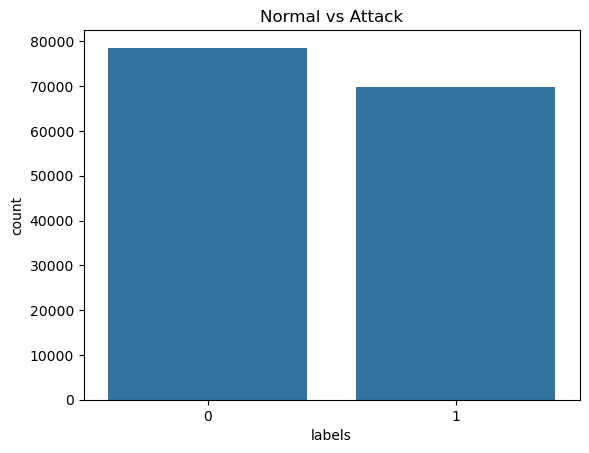

In [27]:
# Visualize number of normal vs attack instances
plt.figure()
sns.countplot(x='labels', data=df)
plt.title("Normal vs Attack")
plt.show()

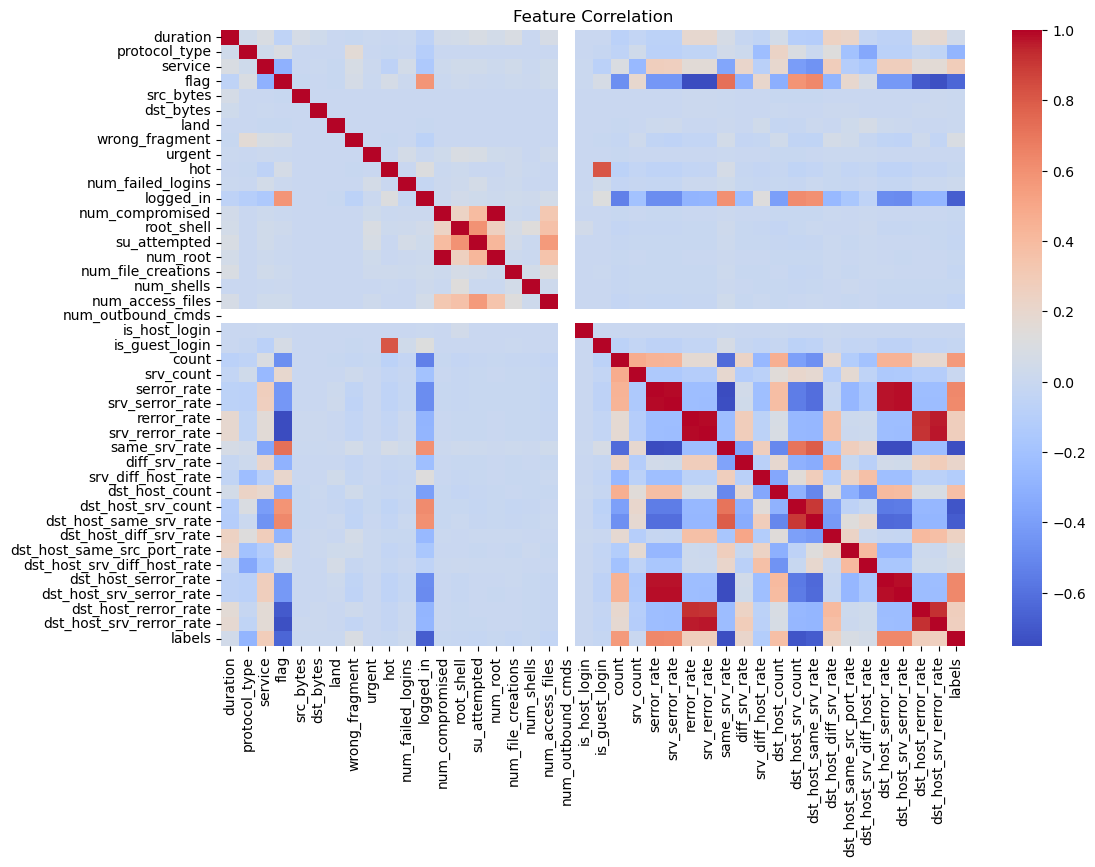

In [28]:
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), cmap='coolwarm')
plt.title("Feature Correlation")
plt.show()

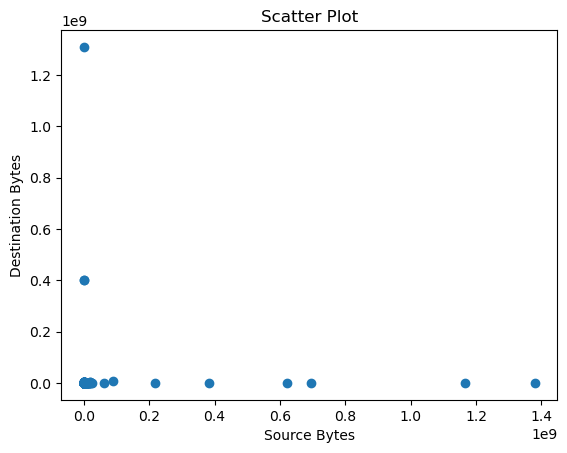

In [29]:
#scatter plot 
plt.figure()
plt.scatter(df['src_bytes'], df['dst_bytes'])
plt.xlabel("Source Bytes")
plt.ylabel("Destination Bytes")
plt.title("Scatter Plot")
plt.show()

In [30]:
#conditional and decisional attributes 
X = df.drop('labels', axis=1)
y = df['labels']

In [31]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = df.drop('labels', axis=1)
y = df['labels']

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [32]:
#running randomforest classifier algorithm that is expected to give more accuracy
rf = RandomForestClassifier(n_estimators=100)
rf.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [33]:
#predict decision based on conditional attributes
y_pred = rf.predict(X_test)

In [34]:
#performance metrics
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Accuracy: 0.9983503905197953
Precision: 0.9983551455338625
Recall: 0.9981409981409981
F1 Score: 0.9982480603525331


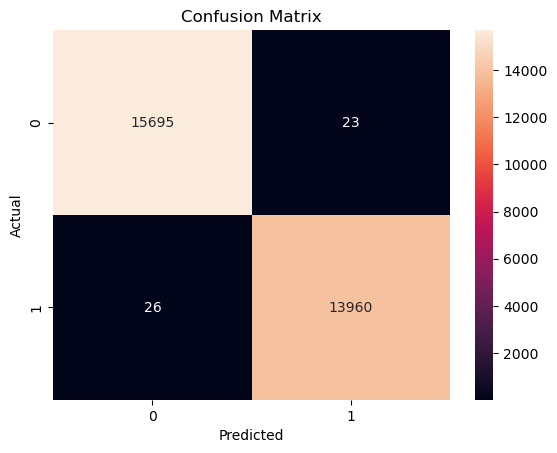

In [35]:
#confusion matrix (predicted vs actual positives and negatives)
cm = confusion_matrix(y_test, y_pred)

plt.figure()
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [36]:
results_df = pd.DataFrame({
    "Actual": y_test,
    "Predicted": y_pred
})

results_df.head(20)

,Actual,Predicted
67300,0,0
105740,1,1
87983,0,0
15813,1,1
65177,0,0
137781,1,1
5318,0,0
1859,0,0
39536,0,0
123770,0,0
